# Gradient Descent and Backpropagation

            ## 1. Learning objectives

            - Calculate one gradient update by hand
- Apply the chain rule
- Verify manual derivatives with autograd

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Determine how every parameter should change to reduce a composed loss function.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Backpropagation assigns responsibility backward; gradient descent takes a small step opposite that responsibility.

## 6. Mathematical foundation

            $$w_{\text{new}}=w-\eta\frac{\partial L}{\partial w}.$$

            **Every symbol:**

            - $w$ is a parameter.
- $\eta$ is learning rate.
- $L$ is loss.
- $\partial L/\partial w$ is loss sensitivity to w.

            **Why the equation is needed:** The negative gradient is the direction of steepest local loss decrease.

            **Small numerical example:** For prediction 2, target 5, x=2, squared-error gradient is 2(2-5)2=-12; with eta=.1, w changes from 1 to 2.2.

            **Connection to Python:** optimizer.step() applies this update after loss.backward() fills parameter gradients.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
x, target, weight, bias, learning_rate = 2.0, 5.0, 1.0, 0.0, .1
prediction = weight*x + bias
loss = (prediction-target)**2
d_loss_d_prediction = 2*(prediction-target)
d_loss_d_weight = d_loss_d_prediction*x
d_loss_d_bias = d_loss_d_prediction
new_weight = weight-learning_rate*d_loss_d_weight
new_bias = bias-learning_rate*d_loss_d_bias
print({"prediction": prediction, "loss": loss, "dW": d_loss_d_weight, "db": d_loss_d_bias, "new_w": new_weight, "new_b": new_bias})

{'prediction': 2.0, 'loss': 9.0, 'dW': -12.0, 'db': -6.0, 'new_w': 2.2, 'new_b': 0.6000000000000001}


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Autograd dW/db: -12.0 -6.0


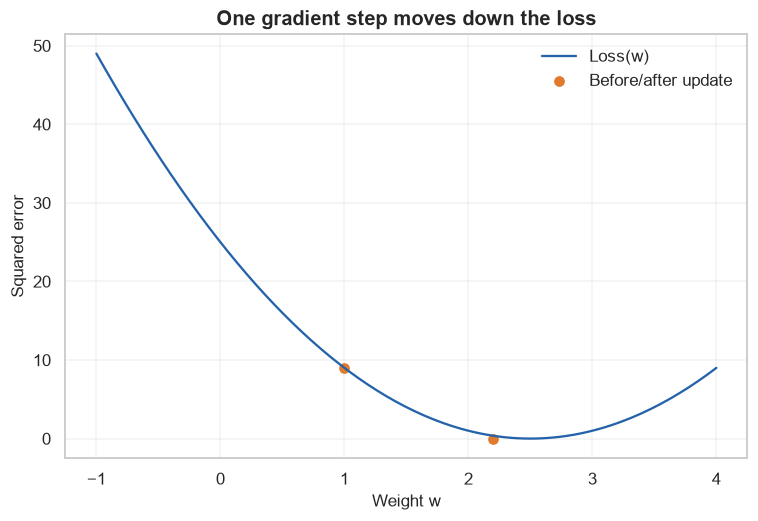

In [3]:
x_t = torch.tensor(2.0)
target_t = torch.tensor(5.0)
weight_t = torch.tensor(1.0, requires_grad=True)
bias_t = torch.tensor(0.0, requires_grad=True)
prediction_t = weight_t*x_t + bias_t
loss_t = (prediction_t-target_t)**2
loss_t.backward()
print("Autograd dW/db:", weight_t.grad.item(), bias_t.grad.item())
assert np.isclose(weight_t.grad.item(), d_loss_d_weight)

grid = np.linspace(-1, 4, 200)
loss_surface = (grid*x-target)**2
figure, axis = plt.subplots()
axis.plot(grid, loss_surface, color=COURSE_COLORS["blue"], label="Loss(w)")
axis.scatter([weight, new_weight], [(weight*x-target)**2, (new_weight*x+new_bias-target)**2], color=COURSE_COLORS["orange"], label="Before/after update")
axis.set(title="One gradient step moves down the loss", xlabel="Weight w", ylabel="Squared error")
axis.legend()
plt.show()

**How to interpret the result:** The manual and autograd gradients agree exactly; the plotted update reduces the local loss.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Learning rate that is too small converges slowly; a large rate can oscillate or diverge.

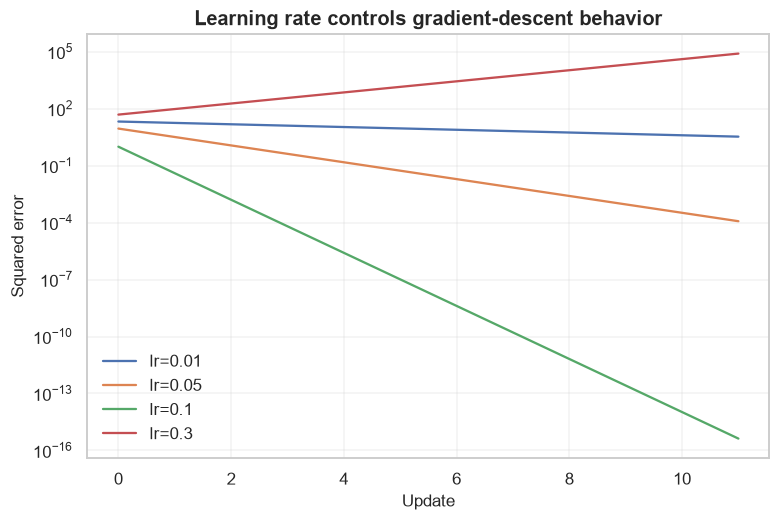

In [4]:
rates = [.01, .05, .1, .3]
histories = {}
for rate in rates:
    current = 0.0
    history = []
    for _ in range(12):
        gradient = 2*(current*x-target)*x
        current -= rate*gradient
        history.append((current*x-target)**2)
    histories[rate] = history
figure, axis = plt.subplots()
for rate, history in histories.items():
    axis.plot(history, label=f"lr={rate}")
axis.set(title="Learning rate controls gradient-descent behavior", xlabel="Update", ylabel="Squared error")
axis.set_yscale("log")
axis.legend()
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)